In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)  
tf.random.set_seed(42)  

In [2]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

appearances = pd.read_csv('./data/Analytics/appearances.csv')
club_games = pd.read_csv('./data/Analytics/club_games.csv')
clubs = pd.read_csv('./data/Analytics/clubs.csv')
competitions = pd.read_csv('./data/Analytics/competitions.csv')
game_events = pd.read_csv('./data/Analytics/game_events.csv')
game_lineups = pd.read_csv('./data/Analytics/game_lineups.csv')
games = pd.read_csv('./data/Analytics/games.csv')
players = pd.read_csv('./data/Analytics/players.csv')
players_club = pd.read_csv('./data/Analytics/players_club.csv')
transfers = pd.read_csv('./data/Analytics/transfers.csv')

### EDA

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19560 entries, 0 to 19559
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   player_id            19560 non-null  int64
 1   market_value_in_eur  19560 non-null  int64
dtypes: int64(2)
memory usage: 305.8 KB


In [4]:
appearances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1706806 entries, 0 to 1706805
Data columns (total 13 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   appearance_id           object
 1   game_id                 int64 
 2   player_id               int64 
 3   player_club_id          int64 
 4   player_current_club_id  int64 
 5   date                    object
 6   player_name             object
 7   competition_id          object
 8   yellow_cards            int64 
 9   red_cards               int64 
 10  goals                   int64 
 11  assists                 int64 
 12  minutes_played          int64 
dtypes: int64(9), object(4)
memory usage: 169.3+ MB


In [5]:
club_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148052 entries, 0 to 148051
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   game_id                148052 non-null  int64  
 1   club_id                148034 non-null  float64
 2   own_goals              148028 non-null  float64
 3   own_position           103118 non-null  float64
 4   own_manager_name       146396 non-null  object 
 5   opponent_id            148034 non-null  float64
 6   opponent_goals         148028 non-null  float64
 7   opponent_position      103118 non-null  float64
 8   opponent_manager_name  146396 non-null  object 
 9   hosting                148052 non-null  object 
 10  is_win                 148052 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 12.4+ MB


In [6]:
clubs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   club_id                  439 non-null    int64  
 1   club_code                439 non-null    object 
 2   name                     439 non-null    object 
 3   domestic_competition_id  439 non-null    object 
 4   total_market_value       0 non-null      float64
 5   squad_size               439 non-null    int64  
 6   average_age              401 non-null    float64
 7   foreigners_number        439 non-null    int64  
 8   foreigners_percentage    390 non-null    float64
 9   national_team_players    439 non-null    int64  
 10  stadium_name             439 non-null    object 
 11  stadium_seats            439 non-null    int64  
 12  net_transfer_record      439 non-null    object 
 13  coach_name               0 non-null      float64
 14  last_season              4

In [7]:
competitions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   competition_id            44 non-null     object
 1   competition_code          44 non-null     object
 2   name                      44 non-null     object
 3   sub_type                  44 non-null     object
 4   type                      44 non-null     object
 5   country_id                44 non-null     int64 
 6   country_name              36 non-null     object
 7   domestic_league_code      36 non-null     object
 8   confederation             44 non-null     object
 9   url                       44 non-null     object
 10  is_major_national_league  44 non-null     bool  
dtypes: bool(1), int64(1), object(9)
memory usage: 3.6+ KB


In [8]:
game_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035043 entries, 0 to 1035042
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   game_event_id     1035043 non-null  object 
 1   date              1035043 non-null  object 
 2   game_id           1035043 non-null  int64  
 3   minute            1035043 non-null  int64  
 4   type              1035043 non-null  object 
 5   club_id           1035043 non-null  int64  
 6   player_id         1035043 non-null  int64  
 7   description       947716 non-null   object 
 8   player_in_id      497678 non-null   float64
 9   player_assist_id  156759 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 79.0+ MB


In [9]:
game_lineups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191911 entries, 0 to 2191910
Data columns (total 10 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   game_lineups_id  object
 1   date             object
 2   game_id          int64 
 3   player_id        int64 
 4   club_id          int64 
 5   player_name      object
 6   type             object
 7   position         object
 8   number           object
 9   team_captain     int64 
dtypes: int64(4), object(6)
memory usage: 167.2+ MB


In [10]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74026 entries, 0 to 74025
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 74026 non-null  int64  
 1   competition_id          74026 non-null  object 
 2   season                  74026 non-null  int64  
 3   round                   74026 non-null  object 
 4   date                    74026 non-null  object 
 5   home_club_id            74017 non-null  float64
 6   away_club_id            74017 non-null  float64
 7   home_club_goals         74014 non-null  float64
 8   away_club_goals         74014 non-null  float64
 9   home_club_position      51559 non-null  float64
 10  away_club_position      51559 non-null  float64
 11  home_club_manager_name  73198 non-null  object 
 12  away_club_manager_name  73198 non-null  object 
 13  stadium                 73776 non-null  object 
 14  attendance              64078 non-null

In [11]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32601 entries, 0 to 32600
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             32601 non-null  int64  
 1   first_name                            30539 non-null  object 
 2   last_name                             32601 non-null  object 
 3   name                                  32601 non-null  object 
 4   last_season                           32601 non-null  int64  
 5   current_club_id                       32601 non-null  int64  
 6   player_code                           32601 non-null  object 
 7   country_of_birth                      29802 non-null  object 
 8   city_of_birth                         30146 non-null  object 
 9   country_of_citizenship                32218 non-null  object 
 10  date_of_birth                         32554 non-null  object 
 11  sub_position   

In [12]:
players_club.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496606 entries, 0 to 496605
Data columns (total 4 columns):
 #   Column                               Non-Null Count   Dtype 
---  ------                               --------------   ----- 
 0   player_id                            496606 non-null  int64 
 1   date                                 496606 non-null  object
 2   current_club_id                      496606 non-null  int64 
 3   player_club_domestic_competition_id  496606 non-null  object
dtypes: int64(2), object(2)
memory usage: 15.2+ MB


In [13]:
transfers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79646 entries, 0 to 79645
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   player_id        79646 non-null  int64  
 1   transfer_date    79646 non-null  object 
 2   transfer_season  79646 non-null  object 
 3   from_club_id     79646 non-null  int64  
 4   to_club_id       79646 non-null  int64  
 5   from_club_name   79646 non-null  object 
 6   to_club_name     79646 non-null  object 
 7   transfer_fee     51931 non-null  float64
 8   player_name      79646 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 5.5+ MB


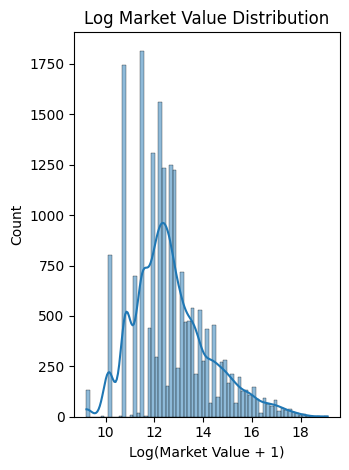

In [14]:
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['market_value_in_eur']), kde=True)
plt.title('Log Market Value Distribution')
plt.xlabel('Log(Market Value + 1)')
plt.tight_layout()
plt.show()

In [15]:
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'])
appearances['date'] = pd.to_datetime(appearances['date'])
transfers['transfer_date'] = pd.to_datetime(transfers['transfer_date'])
players_club['date'] = pd.to_datetime(players_club['date'])
games['date'] = pd.to_datetime(games['date'])

In [16]:
reference_date = pd.to_datetime('2025-01-01')
players['age'] = (reference_date - players['date_of_birth']).dt.days / 365.25

In [17]:
print("Market value statistics:")
print(train['market_value_in_eur'].describe())
print(f"Skewness: {train['market_value_in_eur'].skew()}")

Market value statistics:
count    1.956000e+04
mean     1.639271e+06
std      6.267514e+06
min      1.000000e+04
25%      1.000000e+05
50%      2.500000e+05
75%      7.500000e+05
max      2.000000e+08
Name: market_value_in_eur, dtype: float64
Skewness: 11.773937153503152


### Feature Engineering

In [18]:
appearances['goals_per_90'] = appearances['goals'] * 90 / appearances['minutes_played'].replace(0, 90)
appearances['assists_per_90'] = appearances['assists'] * 90 / appearances['minutes_played'].replace(0, 90)
appearances['goal_contributions'] = appearances['goals'] + appearances['assists']
appearances['contribution_per_90'] = appearances['goal_contributions'] * 90 / appearances['minutes_played'].replace(0, 90)
appearances['cards_total'] = appearances['yellow_cards'] + appearances['red_cards']

In [19]:
player_stats = appearances.groupby('player_id').agg({
    'minutes_played': 'sum',
    'goals': 'sum',
    'assists': 'sum',
    'yellow_cards': 'sum',
    'red_cards': 'sum',
    'goals_per_90': 'mean',
    'assists_per_90': 'mean',
    'contribution_per_90': 'mean'
}).reset_index()

In [20]:
players_club_latest = players_club.sort_values('date').groupby('player_id').last().reset_index()

In [21]:
latest_transfers = transfers.sort_values('transfer_date').groupby('player_id').last().reset_index()

### Encoding

In [22]:
position_mapping = {
    'Attack': 4,
    'Midfield': 3,
    'Defender': 2,
    'Goalkeeper': 1
}
players['position_value'] = players['position'].map(position_mapping)

In [23]:
foot_mapping = {'right': 1, 'left': 2, 'both': 3, '': 0}
players['foot_value'] = players['foot'].map(foot_mapping)

In [24]:
players['is_attack'] = (players['position'] == 'Attack').astype(int)
players['is_midfield'] = (players['position'] == 'Midfield').astype(int)
players['is_defender'] = (players['position'] == 'Defender').astype(int)
players['is_goalkeeper'] = (players['position'] == 'Goalkeeper').astype(int)

### Data Integration

In [25]:
train_df = train.copy()

train_df = train_df.merge(
    players[['player_id', 'position', 'position_value', 'foot', 'height_in_cm', 'age', 'country_of_citizenship']],
    on='player_id', how='left'
)

train_df = train_df.merge(
    players_club_latest[['player_id', 'current_club_id', 'player_club_domestic_competition_id']],
    on='player_id', how='left'
)

train_df = train_df.merge(
    clubs[['club_id', 'squad_size', 'average_age', 'foreigners_percentage', 'national_team_players']],
    left_on='current_club_id', right_on='club_id', how='left'
)

train_df = train_df.merge(
    competitions[['competition_id', 'type', 'is_major_national_league']],
    left_on='player_club_domestic_competition_id', right_on='competition_id', how='left'
)

train_df = train_df.merge(player_stats, on='player_id', how='left')

train_df = train_df.merge(
    latest_transfers[['player_id', 'transfer_fee']], 
    on='player_id', how='left'
)

print("train shape:", train.shape)
print("train_df shape:", train_df.shape)

train shape: (19560, 2)
train_df shape: (19560, 27)


In [26]:
test_df = test.copy()

test_df = test_df.merge(
    players[['player_id', 'position', 'position_value', 'foot', 'height_in_cm', 'age', 'country_of_citizenship']],
    on='player_id', how='left'
)

test_df = test_df.merge(
    players_club_latest[['player_id', 'current_club_id', 'player_club_domestic_competition_id']],
    on='player_id', how='left'
)

test_df = test_df.merge(
    clubs[['club_id', 'squad_size', 'average_age', 'foreigners_percentage', 'national_team_players']],
    left_on='current_club_id', right_on='club_id', how='left'
)

test_df = test_df.merge(
    competitions[['competition_id', 'type', 'is_major_national_league']],
    left_on='player_club_domestic_competition_id', right_on='competition_id', how='left'
)

test_df = test_df.merge(player_stats, on='player_id', how='left')

test_df = test_df.merge(
    latest_transfers[['player_id', 'transfer_fee']], 
    on='player_id', how='left'
)

print("test shape:", test.shape)
print("test_df shape:", test_df.shape)

test shape: (13041, 2)
test_df shape: (13041, 27)


In [27]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,19560.0,3.481227e+05,2.847753e+05,26.000000,108388.000000,283128.500000,530161.000000,1.378362e+06
market_value_in_eur,19560.0,1.639271e+06,6.267514e+06,10000.000000,100000.000000,250000.000000,750000.000000,2.000000e+08
position_value,19452.0,2.727946e+00,9.893341e-01,1.000000,2.000000,3.000000,4.000000,4.000000e+00
height_in_cm,18184.0,1.822993e+02,6.924834e+00,18.000000,178.000000,183.000000,187.000000,2.100000e+02
age,19534.0,2.993197e+01,6.631830e+00,15.315537,24.752909,29.374401,34.453114,5.642163e+01
current_club_id,18617.0,4.663776e+03,1.134728e+04,3.000000,398.000000,1053.000000,3057.000000,1.103020e+05
club_id,18617.0,4.663776e+03,1.134728e+04,3.000000,398.000000,1053.000000,3057.000000,1.103020e+05
squad_size,18617.0,2.529838e+01,7.452008e+00,0.000000,25.000000,26.000000,29.000000,4.100000e+01
average_age,17531.0,2.577151e+01,1.810970e+00,0.000000,24.800000,25.900000,26.900000,2.990000e+01
foreigners_percentage,17215.0,5.036558e+01,1.913383e+01,2.400000,37.900000,51.700000,65.400000,1.000000e+02


In [28]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19560 entries, 0 to 19559
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   player_id                            19560 non-null  int64  
 1   market_value_in_eur                  19560 non-null  int64  
 2   position                             19560 non-null  object 
 3   position_value                       19452 non-null  float64
 4   foot                                 17997 non-null  object 
 5   height_in_cm                         18184 non-null  float64
 6   age                                  19534 non-null  float64
 7   country_of_citizenship               19332 non-null  object 
 8   current_club_id                      18617 non-null  float64
 9   player_club_domestic_competition_id  18617 non-null  object 
 10  club_id                              18617 non-null  float64
 11  squad_size                  

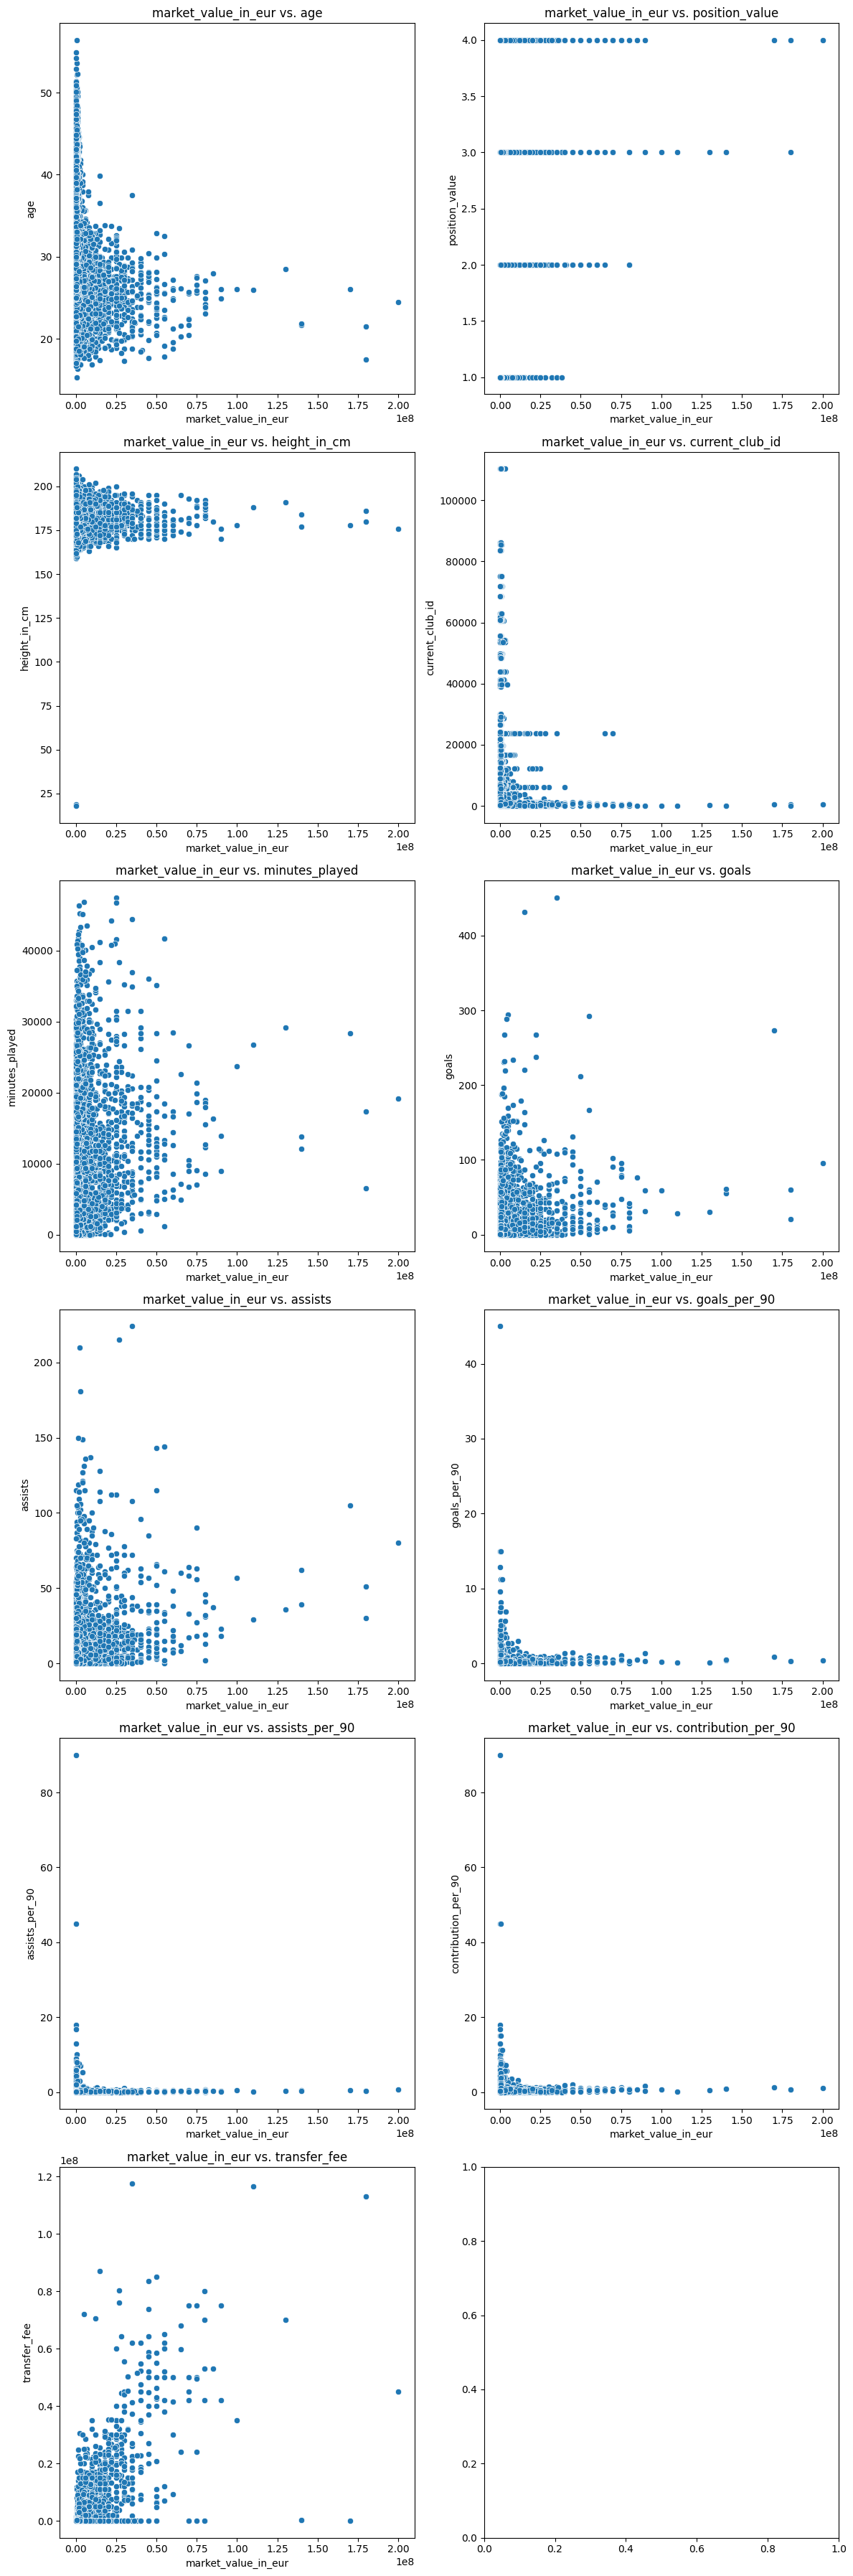

In [29]:
scatter_features = ['age', 'position_value', 'height_in_cm', 'current_club_id', 
                    'minutes_played', 'goals', 'assists', 'goals_per_90', 
                    'assists_per_90', 'contribution_per_90', 'transfer_fee']

n_cols = 2
n_rows = len(scatter_features) // n_cols + (len(scatter_features) % n_cols > 0)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6 * n_rows))

for i, feature in enumerate(scatter_features):
    row = i // n_cols
    col = i % n_cols
    
    sns.scatterplot(data=train_df, y=feature, x='market_value_in_eur', ax=axes[row, col])
    axes[row, col].set_title(f'market_value_in_eur vs. {feature}')
    axes[row, col].set_ylabel(feature)
    axes[row, col].set_xlabel('market_value_in_eur')

plt.tight_layout()
plt.show()

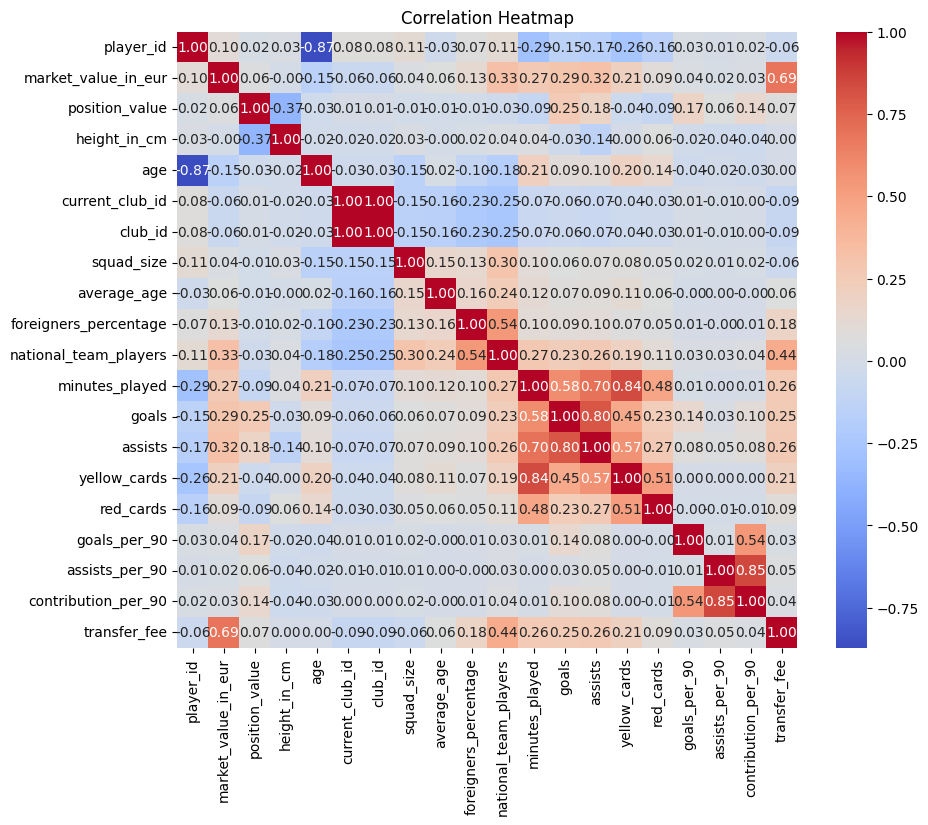

In [30]:
num_col = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix = train_df[num_col].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

### Preprocessing

In [31]:
X = train_df.drop(['player_id', 'market_value_in_eur', 'club_id', 'current_club_id'], axis=1)
y = train_df['market_value_in_eur']

num = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
kategori = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Num features: {len(num)}")
print(f"Categorical features: {len(kategori)}")

Num features: 16
Categorical features: 7


In [32]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num),
        ('cat', categorical_transformer, kategori)
    ]
)

In [34]:
# Apply preprocessing to train, val
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print(f"Shape of processed training data: {X_train_processed.shape}")

Shape of processed training data: (15648, 218)


In [35]:
# Log transform menangani skewness pada label
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

### Modeling

In [36]:
nn_model = Sequential([
    # Input layer
    layers.Dense(256, activation='relu', input_dim=X_train_processed.shape[1]),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    # Hidden layers
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    
    # Output layer - regresi
    layers.Dense(1)
])

In [37]:
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=[
        'mean_absolute_error',                              # MAE: intuisi error dalam unit asli
        tf.keras.metrics.RootMeanSquaredError(name='rmse')  # RMSE: skala error MSE diubah kembali
    ]
)

In [38]:
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        56,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,249 (395.50 KB)

 Trainable params: 100,289 (391.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [39]:
callbacks_list = [
    # Early stopping untuk mencegah overfitting
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    ),
    # Learning rate reduction
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=0.00001
    )
]

In [40]:
history = nn_model.fit(
    X_train_processed, y_train_log,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_processed, y_val_log),
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/200
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 126.8891 - mean_absolute_error: 10.8779 - rmse: 11.2047 - val_loss: 5.2143 - val_mean_absolute_error: 1.9271 - val_rmse: 2.2835 - learning_rate: 0.0010
Epoch 2/200
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.5415 - mean_absolute_error: 1.8402 - rmse: 2.3483 - val_loss: 1.9226 - val_mean_absolute_error: 1.0470 - val_rmse: 1.3866 - learning_rate: 0.0010
Epoch 3/200
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.4889 - mean_absolute_error: 1.4647 - rmse: 1.8677 - val_loss: 1.6378 - val_mean_absolute_error: 0.9926 - val_rmse: 1.2798 - learning_rate: 0.0010
Epoch 4/200
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.8604 - mean_absolute_error: 1.3213 - rmse: 1.6911 - val_loss: 1.5468 - val_mean_absolute_error: 0.9584 - val_rmse: 1.2437 - learning_rate: 0.0010
Epoch 5/200
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6687 - mean_absolute_error: 1.2725 - rmse: 1.6335 - val_loss: 1.4836 - val_mean_absolute_error: 0

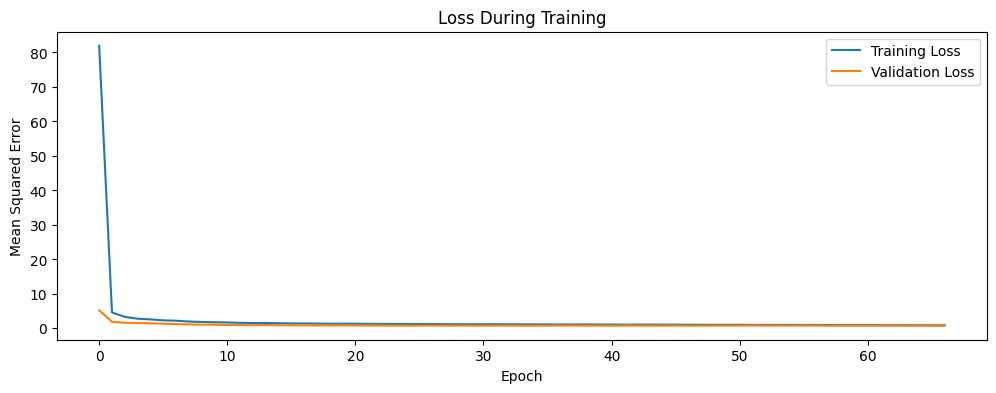

In [41]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()

In [42]:
val_preds_log = nn_model.predict(X_val_processed).flatten()
val_preds = np.expm1(val_preds_log)  # Ubah kembali dari skala log

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [43]:
log_rmse = np.sqrt(mean_squared_error(y_val_log, val_preds_log))
log_mae  = mean_absolute_error(y_val_log, val_preds_log)

print(f"\nLog Scale Performance:")
print(f"Log RMSE: {log_rmse:.4f}")


Log Scale Performance:
Log RMSE: 0.8783


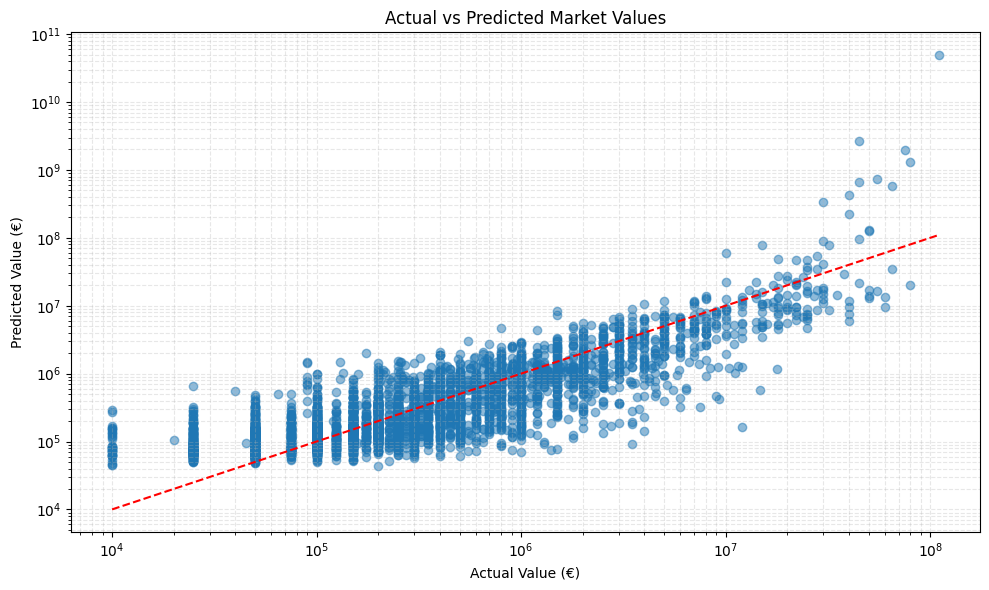

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(y_val, val_preds, alpha=0.5)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--')
plt.title('Actual vs Predicted Market Values')
plt.xlabel('Actual Value (€)')
plt.ylabel('Predicted Value (€)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
X_test = test_df.drop(['player_id', 'market_value_in_eur', 'club_id', 'current_club_id'], axis=1)
X_test_processed = preprocessor.transform(X_test)
test_preds_log = nn_model.predict(X_test_processed).flatten()
test_preds = np.expm1(test_preds_log)

408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [46]:
submission = pd.DataFrame({
    'player_id': test_df['player_id'],
    'market_value_in_eur': test_preds
})

In [47]:
submission.describe()

,player_id,market_value_in_eur
count,1.304100e+04,1.304100e+04
mean,3.485976e+05,1.014286e+07
std,2.841196e+05,5.737791e+08
min,1.000000e+01,1.008134e+04
25%,1.077750e+05,1.229171e+05
50%,2.849900e+05,2.235484e+05
75%,5.302580e+05,6.489577e+05
max,1.391239e+06,5.080363e+10


In [48]:
submission.to_csv('submission.csv', index=False)